# 314Ah 多区域并联 DFN 分布耦合

把一个 314Ah 电芯沿大面近似为三个并联区域：A 拐角（10%）、B 大面中部（70%）、C 顶部（20%）。每个区域都是独立的 PyBaMM DFN，拥有自己的浓度、SOC 和极化状态；外部耦合只施加两个约束：

- 端电压相等：$V_A=V_B=V_C$
- 电流守恒：$I_A+I_B+I_C=I_{cell}$

本 Notebook 对比健康电芯与“A 区局部低孔隙率”电芯，重点展示 macro-step 内的回滚试算、电流重分配、收敛判据和后处理。

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import importlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pybamm
from IPython.display import display

cwd = Path.cwd().resolve()
WORKSPACE_ROOT = next(
    p for p in (cwd, *cwd.parents)
    if (p / "BatteryProject").exists() and (p / "params").exists()
)
PROJECT_ROOT = WORKSPACE_ROOT / "BatteryProject"
for item in (WORKSPACE_ROOT, PROJECT_ROOT):
    if str(item) not in sys.path:
        sys.path.insert(0, str(item))

from params import load_cell_params
import src.simulation_regional_parallel as regional_parallel
importlib.reload(regional_parallel)
from src.simulation_regional_parallel import RegionalDFNConfig, run_regional_dfn_coupling

try:
    plt.style.use("science")
except Exception:
    pass
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "Calibri", "Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 130

EXPECTED_PYBAMM_MAJOR = "26."
if not pybamm.__version__.startswith(EXPECTED_PYBAMM_MAJOR):
    raise RuntimeError(
        "当前 Notebook kernel 不正确。请选择 'Hithium PyBaMM 26.4.2'。\n"
        f"当前解释器: {sys.executable}\n当前 PyBaMM: {pybamm.__version__}"
    )

print(f"Python: {sys.executable}")
print(f"PyBaMM: {pybamm.__version__}")
print(f"Workspace: {WORKSPACE_ROOT}")

Python: C:\Users\hez\AppData\Local\Programs\Python\Python311\python.exe
PyBaMM: 26.4.2
Workspace: C:\HithiumSSD\hithium


## 计算方法

每个 60 s macro step 内，三套 DFN 都从同一个“上一步已接受状态”重新试算，试算不会累积时间。根据当前试算得到的表面 OCV 和端电压构造区域表观电阻：

$$R_k^{app}=\left|rac{OCV_k-V_k}{I_k}ight|$$

随后解并联 $OCV+R$ 网络得到新电流，按松弛系数更新，再从旧状态重算。只有同时满足 `KCL error < 1e-6 A` 和 `regional voltage spread < 1 mV` 才提交该步 DFN 状态。

In [2]:
TEMPERATURE_K = 298.15
INITIAL_SOC = 0.50
NOMINAL_CAPACITY_AH = 314.0
TOTAL_CURRENT_A = 0.25 * NOMINAL_CAPACITY_AH
DURATION_S = 10 * 60
MACRO_STEP_S = 60.0
RELAXATION = 0.70
POROSITY_FACTOR_A = 0.30

AREA_FRACTIONS = {"A_corner": 0.10, "B_middle": 0.70, "C_top": 0.20}
POROSITY_PARAMETERS = (
    "Negative electrode porosity",
    "Separator porosity",
    "Positive electrode porosity",
)
VAR_PTS = {"x_n": 5, "x_s": 5, "x_p": 5, "r_n": 20, "r_p": 20}


def make_314_parameter_values():
    # 每次独立创建，避免 ParameterValues 在不同算例间污染。
    params = pybamm.ParameterValues("OKane2022")
    params.update(
        load_cell_params("314")(1, TEMPERATURE_K),
        check_already_exists=False,
    )
    return params


RUN_KWARGS = dict(
    total_current_a=TOTAL_CURRENT_A,
    duration_s=DURATION_S,
    macro_step_s=MACRO_STEP_S,
    initial_soc=INITIAL_SOC,
    var_pts=VAR_PTS,
    rtol=1e-6,
    atol=1e-6,
    max_iterations=12,
    kcl_tolerance_a=1e-6,
    voltage_tolerance_v=1e-3,
    relaxation=RELAXATION,
)

print(f"工况: {TOTAL_CURRENT_A:.2f} A ({TOTAL_CURRENT_A / NOMINAL_CAPACITY_AH:.2f}C), "
      f"{DURATION_S / 60:.0f} min, {TEMPERATURE_K - 273.15:.0f} °C, SOC={INITIAL_SOC:.0%}")

工况: 78.50 A (0.25C), 10 min, 25 °C, SOC=50%


In [3]:
base_preview = make_314_parameter_values()
healthy_configs = tuple(
    RegionalDFNConfig(name, fraction)
    for name, fraction in AREA_FRACTIONS.items()
)
blocked_configs = tuple(
    RegionalDFNConfig(
        name,
        fraction,
        parameter_multipliers=(
            {parameter: POROSITY_FACTOR_A for parameter in POROSITY_PARAMETERS}
            if name == "A_corner" else {}
        ),
    )
    for name, fraction in AREA_FRACTIONS.items()
)

parameter_rows = []
for name, fraction in AREA_FRACTIONS.items():
    row = {
        "region": name,
        "area_fraction": fraction,
        "regional_capacity_Ah": NOMINAL_CAPACITY_AH * fraction,
    }
    for parameter in POROSITY_PARAMETERS:
        base_value = float(base_preview[parameter])
        row[f"healthy_{parameter}"] = base_value
        row[f"blocked_{parameter}"] = (
            base_value * POROSITY_FACTOR_A if name == "A_corner" else base_value
        )
    parameter_rows.append(row)
parameter_df = pd.DataFrame(parameter_rows)
display(parameter_df.round(5))

,region,area_fraction,regional_capacity_Ah,healthy_Negative electrode porosity,blocked_Negative electrode porosity,healthy_Separator porosity,blocked_Separator porosity,healthy_Positive electrode porosity,blocked_Positive electrode porosity
0,A_corner,0.1,31.4,0.29065,0.08720,0.38,0.114,0.26426,0.07928
1,B_middle,0.7,219.8,0.29065,0.29065,0.38,0.380,0.26426,0.26426
2,C_top,0.2,62.8,0.29065,0.29065,0.38,0.380,0.26426,0.26426


## 执行两套三分支 DFN

健康算例用于验证面积缩放后仍保持 10%/70%/20% 电流分配；局部堵孔算例只修改 A 区参数副本，不修改 `params314.py`，也不改变 B/C 的孔隙率。

In [4]:
start = time.perf_counter()
healthy_result = run_regional_dfn_coupling(
    make_314_parameter_values(),
    healthy_configs,
    **RUN_KWARGS,
)
healthy_runtime_s = time.perf_counter() - start
print(f"健康算例完成: {healthy_runtime_s:.2f} s")

健康算例完成: 2.28 s


In [5]:
start = time.perf_counter()
blocked_result = run_regional_dfn_coupling(
    make_314_parameter_values(),
    blocked_configs,
    **RUN_KWARGS,
)
blocked_runtime_s = time.perf_counter() - start
print(f"A区局部堵孔算例完成: {blocked_runtime_s:.2f} s")

A区局部堵孔算例完成: 2.05 s


In [6]:
healthy_steps = pd.DataFrame(healthy_result.steps()).assign(case="healthy")
blocked_steps = pd.DataFrame(blocked_result.steps()).assign(case="A_porosity_30pct")
all_steps = pd.concat([healthy_steps, blocked_steps], ignore_index=True)

healthy_iterations = pd.DataFrame(healthy_result.iterations()).assign(case="healthy")
blocked_iterations = pd.DataFrame(blocked_result.iterations()).assign(case="A_porosity_30pct")
all_iterations = pd.concat([healthy_iterations, blocked_iterations], ignore_index=True)

accepted_summary = (
    all_steps.groupby("case", as_index=False)
    .agg(
        max_kcl_error_A=("kcl_error_a", "max"),
        max_voltage_spread_mV=("voltage_spread_v", lambda x: 1000 * x.max()),
        max_iterations=("iterations", "max"),
        final_terminal_voltage_V=("terminal_voltage_v", "last"),
    )
)
display(accepted_summary.round(8))

final_currents = (
    all_steps.sort_values("time_s")
    .groupby(["case", "region"], as_index=False)
    .tail(1)[["case", "region", "current_a", "c_rate", "voltage_v", "apparent_resistance_ohm"]]
)
display(final_currents.round(6))

,case,max_kcl_error_A,max_voltage_spread_mV,max_iterations,final_terminal_voltage_V
0,A_porosity_30pct,0.0,0.703888,4,3.246351
1,healthy,0.0,0.000212,1,3.247651


,case,region,current_a,c_rate,voltage_v,apparent_resistance_ohm
57,A_porosity_30pct,A_corner,4.710914,0.150029,3.245951,0.005319
29,healthy,C_top,15.700000,0.250000,3.247651,0.001479
28,healthy,B_middle,54.950000,0.250000,3.247651,0.000423
27,healthy,A_corner,7.850000,0.250000,3.247651,0.002958
58,A_porosity_30pct,B_middle,57.391674,0.261109,3.246550,0.000423
59,A_porosity_30pct,C_top,16.397412,0.261105,3.246551,0.001479


## 整体端电压变化

整体电压由每个已接受 macro-step 的三区域共同端电压得到。下面同时给出健康/局部堵孔的绝对端电压、相对各自第一个接受步的变化，以及局部堵孔相对健康算例的电压差。

,time_min,healthy,A_porosity_30pct,blocked_minus_healthy_mV
0,1.0,3.248105,3.246921,-1.183564
1,2.0,3.248041,3.246787,-1.254005
2,3.0,3.248010,3.246765,-1.245608
3,4.0,3.248025,3.246775,-1.250079
4,5.0,3.248013,3.246750,-1.263398
5,6.0,3.247997,3.246734,-1.263519
6,7.0,3.247944,3.246662,-1.282811
7,8.0,3.247879,3.246585,-1.293964
8,9.0,3.247752,3.246463,-1.288613
9,10.0,3.247651,3.246351,-1.300812


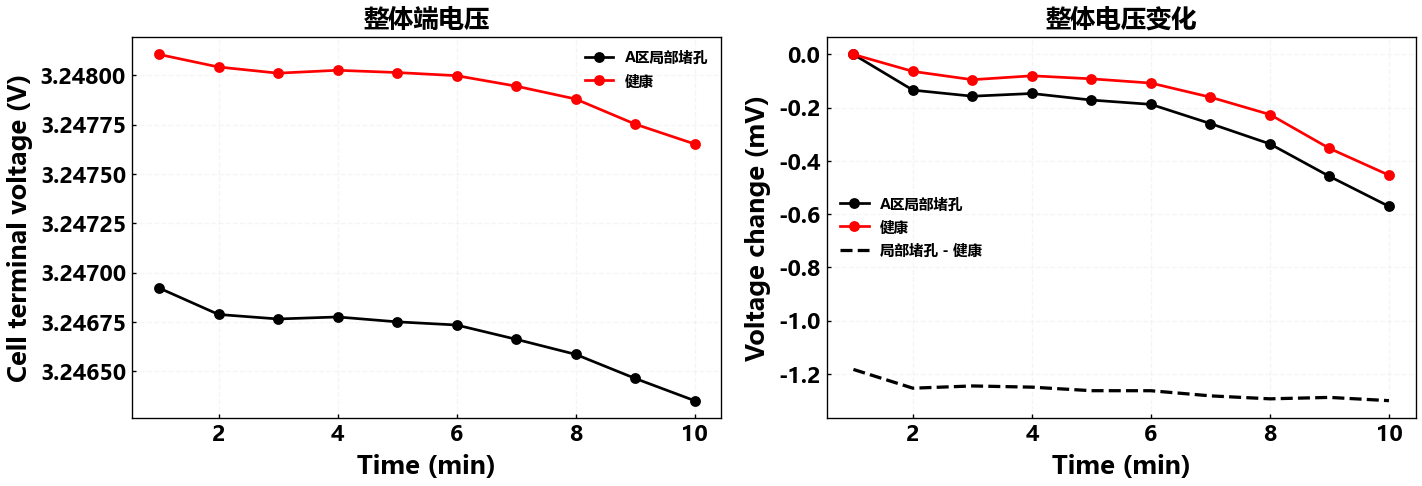

In [7]:
cell_voltage = (
    all_steps.drop_duplicates(["case", "time_s"])
    [["case", "time_s", "terminal_voltage_v"]]
    .sort_values(["case", "time_s"])
    .copy()
)
cell_voltage["delta_from_first_step_mV"] = (
    cell_voltage["terminal_voltage_v"]
    - cell_voltage.groupby("case")["terminal_voltage_v"].transform("first")
) * 1000

voltage_wide = (
    cell_voltage.pivot(index="time_s", columns="case", values="terminal_voltage_v")
    .reset_index()
    .rename_axis(columns=None)
)
voltage_wide["blocked_minus_healthy_mV"] = (
    voltage_wide["A_porosity_30pct"] - voltage_wide["healthy"]
) * 1000
voltage_wide["time_min"] = voltage_wide["time_s"] / 60
display(voltage_wide[["time_min", "healthy", "A_porosity_30pct", "blocked_minus_healthy_mV"]].round(6))

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0))
for case, group in cell_voltage.groupby("case"):
    label = "健康" if case == "healthy" else "A区局部堵孔"
    axes[0].plot(group["time_s"] / 60, group["terminal_voltage_v"], "o-", label=label)
    axes[1].plot(group["time_s"] / 60, group["delta_from_first_step_mV"], "o-", label=label)
axes[1].plot(
    voltage_wide["time_min"],
    voltage_wide["blocked_minus_healthy_mV"],
    "k--",
    linewidth=1.8,
    label="局部堵孔 - 健康",
)
axes[0].set_xlabel("Time (min)")
axes[0].set_ylabel("Cell terminal voltage (V)")
axes[0].set_title("整体端电压")
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("Voltage change (mV)")
axes[1].set_title("整体电压变化")
for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Macro-step 迭代过程

下表和收敛图直接来自每一次回滚试算。健康算例的三分支参数相同，面积电流初值已经满足等压；局部堵孔算例需要把 A 区电流转移给 B/C。

,case,step,step_end_s,iteration,current_update_a,kcl_error_a,voltage_spread_v,converged,voltage_spread_mV
0,healthy,1,60.0,1,0.000088,0.0,2.000000e-07,True,0.000212
3,healthy,2,120.0,1,0.000007,0.0,0.000000e+00,True,0.000034
6,healthy,3,180.0,1,0.000002,0.0,0.000000e+00,True,0.000011
9,healthy,4,240.0,1,0.000003,0.0,0.000000e+00,True,0.000019
12,healthy,5,300.0,1,0.000008,0.0,0.000000e+00,True,0.000030
15,healthy,6,360.0,1,0.000009,0.0,0.000000e+00,True,0.000044
18,healthy,7,420.0,1,0.000014,0.0,0.000000e+00,True,0.000033
21,healthy,8,480.0,1,0.000006,0.0,0.000000e+00,True,0.000014
24,healthy,9,540.0,1,0.000017,0.0,0.000000e+00,True,0.000044
27,healthy,10,600.0,1,0.000022,0.0,1.000000e-07,True,0.000059


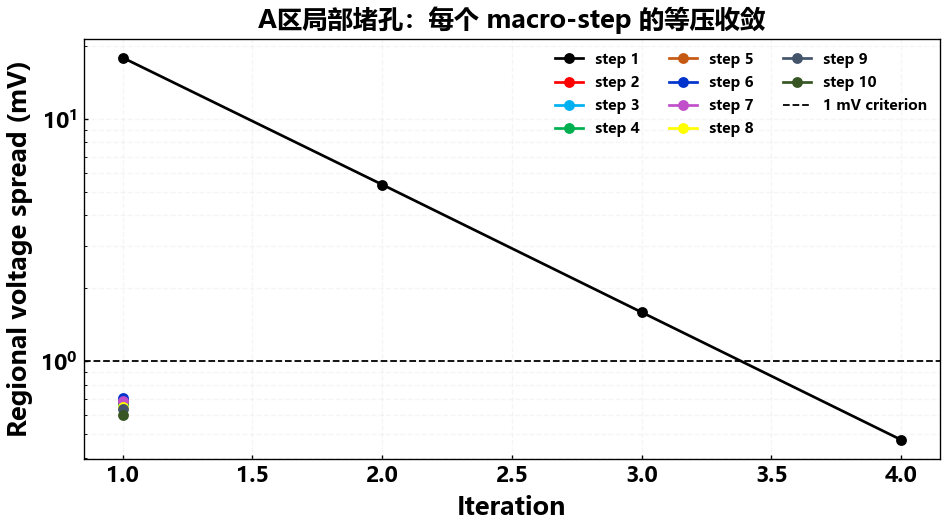

In [8]:
iteration_summary = (
    all_iterations.drop_duplicates(["case", "step", "iteration"])
    [["case", "step", "step_end_s", "iteration", "current_update_a", "kcl_error_a", "voltage_spread_v", "converged"]]
    .copy()
)
iteration_summary["voltage_spread_mV"] = 1000 * iteration_summary["voltage_spread_v"]
display(iteration_summary.head(20).round(7))

fig, ax = plt.subplots(figsize=(8.5, 4.2))
blocked_convergence = iteration_summary[iteration_summary["case"] == "A_porosity_30pct"]
for step, group in blocked_convergence.groupby("step"):
    ax.semilogy(group["iteration"], group["voltage_spread_mV"], "o-", label=f"step {step}")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.0, label="1 mV criterion")
ax.set_xlabel("Iteration")
ax.set_ylabel("Regional voltage spread (mV)")
ax.set_title("A区局部堵孔：每个 macro-step 的等压收敛")
ax.grid(True, which="both", alpha=0.25)
ax.legend(ncol=3, fontsize=8)
plt.show()

## 电流重分配与整体响应

后处理同时看区域电流、区域 C-rate、端电压和等压误差。若局部 A 区堵孔，预期 A 区主动“卸载”，B/C 维持共同端电压；因此整体电压变化远小于把全电芯孔隙率统一压低的 1D 假设。

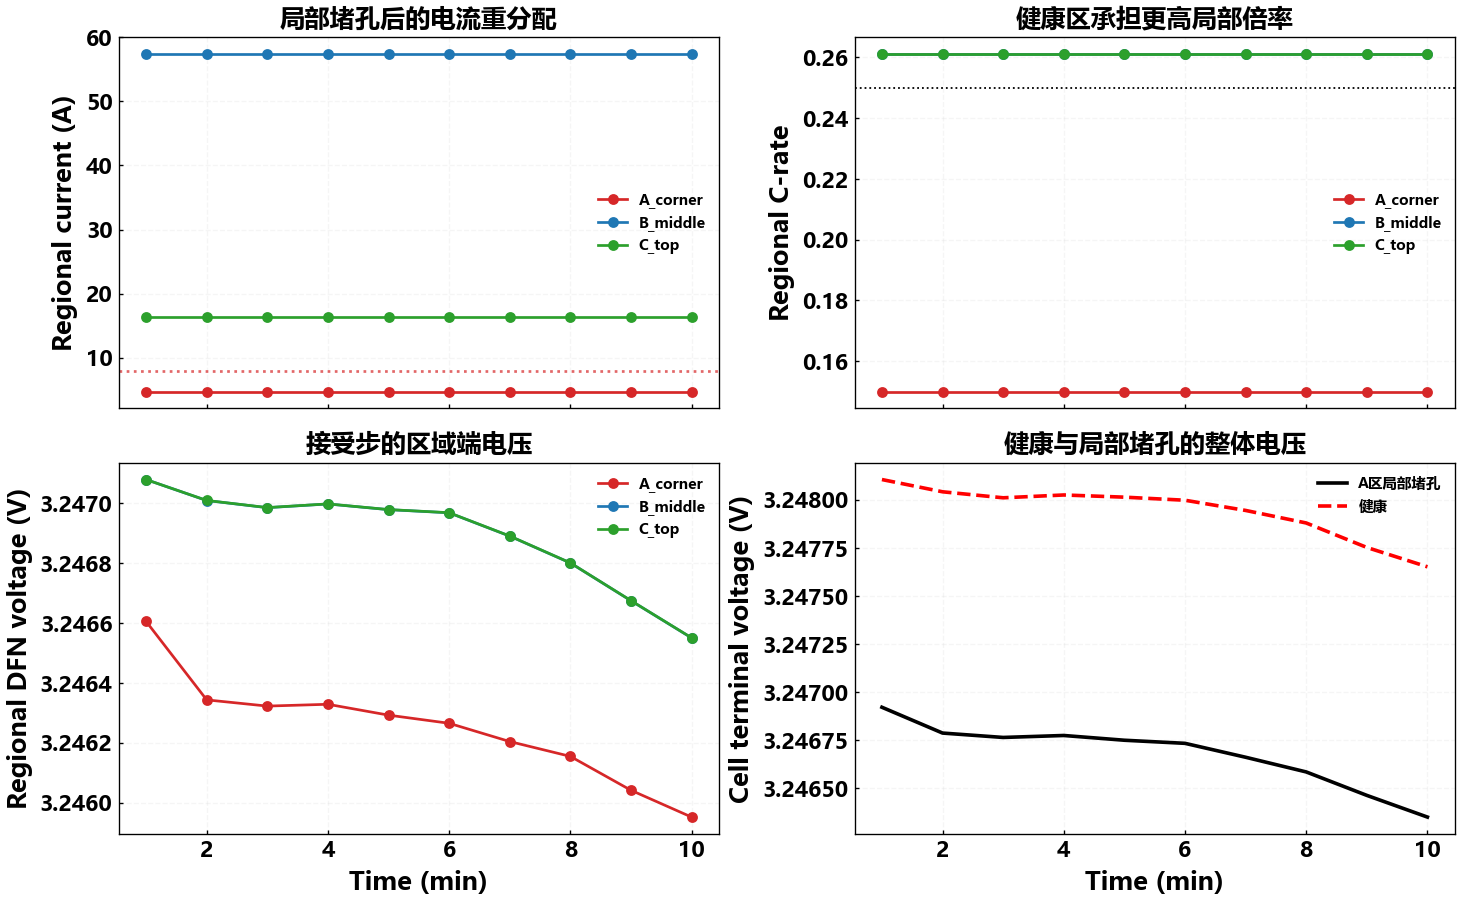

In [9]:
colors = {"A_corner": "#d62728", "B_middle": "#1f77b4", "C_top": "#2ca02c"}
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.2), sharex=True)

for region, group in blocked_steps.groupby("region"):
    axes[0, 0].plot(group["time_s"] / 60, group["current_a"], "o-", color=colors[region], label=region)
    axes[0, 1].plot(group["time_s"] / 60, group["c_rate"], "o-", color=colors[region], label=region)
    axes[1, 0].plot(group["time_s"] / 60, group["voltage_v"], "o-", color=colors[region], label=region)

for case, group in all_steps.groupby("case"):
    terminal = group.groupby("time_s", as_index=False)["terminal_voltage_v"].first()
    label = "健康" if case == "healthy" else "A区局部堵孔"
    style = "--" if case == "healthy" else "-"
    axes[1, 1].plot(terminal["time_s"] / 60, terminal["terminal_voltage_v"], style, linewidth=2, label=label)

axes[0, 0].axhline(TOTAL_CURRENT_A * AREA_FRACTIONS["A_corner"], color=colors["A_corner"], linestyle=":", alpha=0.7)
axes[0, 0].set_ylabel("Regional current (A)")
axes[0, 0].set_title("局部堵孔后的电流重分配")
axes[0, 1].axhline(0.25, color="black", linestyle=":", linewidth=1)
axes[0, 1].set_ylabel("Regional C-rate")
axes[0, 1].set_title("健康区承担更高局部倍率")
axes[1, 0].set_xlabel("Time (min)")
axes[1, 0].set_ylabel("Regional DFN voltage (V)")
axes[1, 0].set_title("接受步的区域端电压")
axes[1, 1].set_xlabel("Time (min)")
axes[1, 1].set_ylabel("Cell terminal voltage (V)")
axes[1, 1].set_title("健康与局部堵孔的整体电压")

for ax in axes.flat:
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## A/B/C 区域孔隙率历史

耦合器在每个已接受 macro-step 记录负极、隔膜、正极的区域平均孔隙率。当前 10 min Notebook 只验证局部堵孔和电流重分配，未启用 SEI/析锂导致的动态孔隙率演化，因此预期曲线保持不变：A 区从较低孔隙率开始，B/C 保持健康值。后续启用老化选项后，同一后处理会直接显示各区域孔隙率随循环变化。

,case,region,section_label,initial_porosity,final_porosity,porosity_change,relative_change_pct
0,A_porosity_30pct,A_corner,正极,0.079278,0.079278,-0.0,-0.0
3,A_porosity_30pct,B_middle,正极,0.264260,0.264260,-0.0,-0.0
6,A_porosity_30pct,C_top,正极,0.264260,0.264260,-0.0,-0.0
1,A_porosity_30pct,A_corner,负极,0.087195,0.087195,0.0,0.0
4,A_porosity_30pct,B_middle,负极,0.290650,0.290650,0.0,0.0
7,A_porosity_30pct,C_top,负极,0.290650,0.290650,0.0,0.0
2,A_porosity_30pct,A_corner,隔膜,0.114000,0.114000,0.0,0.0
5,A_porosity_30pct,B_middle,隔膜,0.380000,0.380000,0.0,0.0
8,A_porosity_30pct,C_top,隔膜,0.380000,0.380000,0.0,0.0


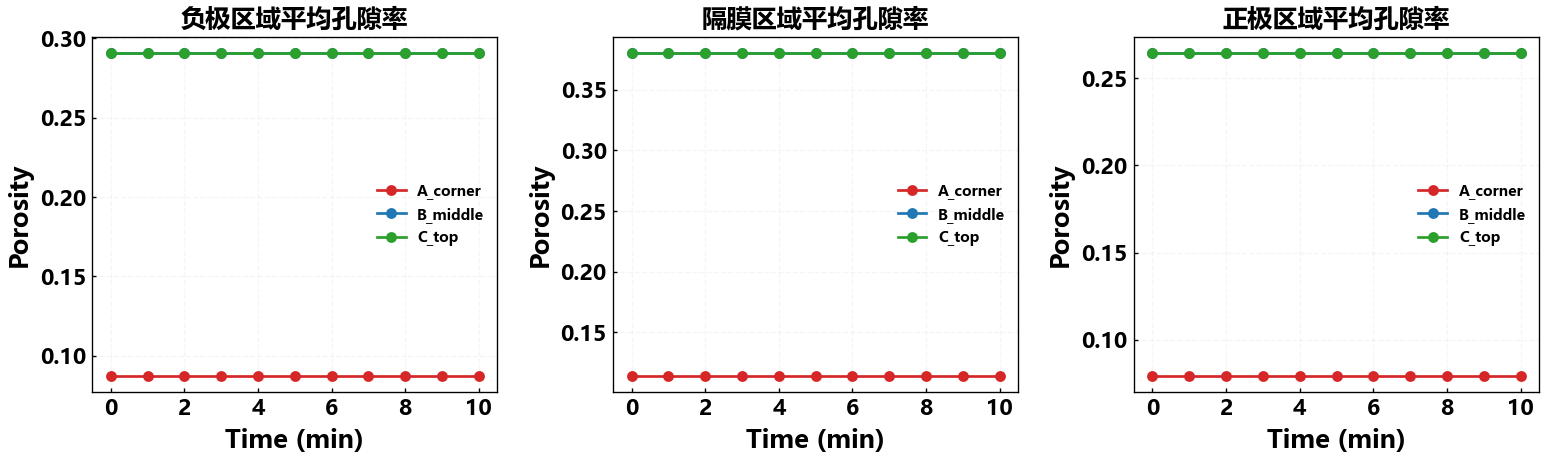

In [10]:
POROSITY_OUTPUTS = {
    "negative_porosity": ("Negative electrode porosity", "负极"),
    "separator_porosity": ("Separator porosity", "隔膜"),
    "positive_porosity": ("Positive electrode porosity", "正极"),
}

initial_porosity_rows = []
for case in ("healthy", "A_porosity_30pct"):
    for region, area_fraction in AREA_FRACTIONS.items():
        row = {"case": case, "time_s": 0.0, "region": region, "area_fraction": area_fraction}
        factor = POROSITY_FACTOR_A if case == "A_porosity_30pct" and region == "A_corner" else 1.0
        for column, (parameter_name, _) in POROSITY_OUTPUTS.items():
            row[column] = float(base_preview[parameter_name]) * factor
        initial_porosity_rows.append(row)

porosity_history = pd.concat(
    [
        pd.DataFrame(initial_porosity_rows),
        all_steps[["case", "time_s", "region", "area_fraction", *POROSITY_OUTPUTS]],
    ],
    ignore_index=True,
).sort_values(["case", "region", "time_s"])

porosity_long = porosity_history.melt(
    id_vars=["case", "time_s", "region", "area_fraction"],
    value_vars=list(POROSITY_OUTPUTS),
    var_name="section",
    value_name="porosity",
)
porosity_long["section_label"] = porosity_long["section"].map(
    {column: label for column, (_, label) in POROSITY_OUTPUTS.items()}
)
porosity_summary = (
    porosity_long.groupby(["case", "region", "section_label"], as_index=False)
    .agg(initial_porosity=("porosity", "first"), final_porosity=("porosity", "last"))
)
porosity_summary["porosity_change"] = (
    porosity_summary["final_porosity"] - porosity_summary["initial_porosity"]
)
porosity_summary["relative_change_pct"] = (
    porosity_summary["porosity_change"] / porosity_summary["initial_porosity"] * 100
)
display(
    porosity_summary[porosity_summary["case"] == "A_porosity_30pct"]
    .sort_values(["section_label", "region"])
    .round(8)
)

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.8), sharex=True)
blocked_porosity = porosity_long[porosity_long["case"] == "A_porosity_30pct"]
for ax, (column, (_, section_label)) in zip(axes, POROSITY_OUTPUTS.items()):
    section_data = blocked_porosity[blocked_porosity["section"] == column]
    for region, group in section_data.groupby("region"):
        ax.plot(group["time_s"] / 60, group["porosity"], "o-", color=colors[region], label=region)
    ax.set_title(f"{section_label}区域平均孔隙率")
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Porosity")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [11]:
healthy_final = healthy_steps.sort_values("time_s").groupby("region").tail(1).set_index("region")
blocked_final = blocked_steps.sort_values("time_s").groupby("region").tail(1).set_index("region")

summary = pd.DataFrame(
    {
        "metric": [
            "A区电流变化",
            "B区电流变化",
            "C区电流变化",
            "10 min整体端电压变化",
            "局部堵孔最大等压误差",
            "局部堵孔最大KCL误差",
        ],
        "value": [
            f"{blocked_final.loc['A_corner', 'current_a'] - healthy_final.loc['A_corner', 'current_a']:.3f} A",
            f"{blocked_final.loc['B_middle', 'current_a'] - healthy_final.loc['B_middle', 'current_a']:.3f} A",
            f"{blocked_final.loc['C_top', 'current_a'] - healthy_final.loc['C_top', 'current_a']:.3f} A",
            f"{1000 * (blocked_final['terminal_voltage_v'].iloc[0] - healthy_final['terminal_voltage_v'].iloc[0]):.3f} mV",
            f"{1000 * blocked_steps['voltage_spread_v'].max():.4f} mV",
            f"{blocked_steps['kcl_error_a'].max():.3e} A",
        ],
    }
)
display(summary)

assert blocked_steps["kcl_error_a"].max() < 1e-6
assert blocked_steps["voltage_spread_v"].max() < 1e-3
assert blocked_final.loc["A_corner", "current_a"] < healthy_final.loc["A_corner", "current_a"]
print("验收通过：局部堵孔区域卸载，健康区域接管电流，所有接受步满足 KCL 与等压判据。")

,metric,value
0,A区电流变化,-3.139 A
1,B区电流变化,2.442 A
2,C区电流变化,0.697 A
3,10 min整体端电压变化,-1.301 mV
4,局部堵孔最大等压误差,0.7039 mV
5,局部堵孔最大KCL误差,1.208e-12 A


验收通过：局部堵孔区域卸载，健康区域接管电流，所有接受步满足 KCL 与等压判据。
